# **1. Perkenalan Dataset**


## Dataset: Diabetes Prediction Dataset

**Sumber:** [Kaggle - Diabetes Prediction Dataset](https://www.kaggle.com/datasets/iammustafatz/diabetes-prediction-dataset)

### Deskripsi Dataset
Dataset ini berisi data medis dan demografis pasien yang digunakan untuk memprediksi kemungkinan seseorang menderita diabetes. Dataset ini terdiri dari **100.000 baris** dan **9 kolom**, menjadikannya dataset yang cukup representatif untuk tugas klasifikasi biner.

### Fitur Dataset
| Fitur | Tipe | Deskripsi |
|---|---|---|
| `gender` | Kategorikal | Jenis kelamin pasien (Male/Female/Other) |
| `age` | Numerik | Usia pasien (0-80 tahun) |
| `hypertension` | Biner (0/1) | Riwayat hipertensi |
| `heart_disease` | Biner (0/1) | Riwayat penyakit jantung |
| `smoking_history` | Kategorikal | Riwayat merokok (never/former/current/etc.) |
| `bmi` | Numerik | Body Mass Index |
| `HbA1c_level` | Numerik | Kadar HbA1c dalam darah |
| `blood_glucose_level` | Numerik | Kadar glukosa darah |
| `diabetes` | Biner (0/1) | **Label Target** - 1 = Diabetes, 0 = Tidak Diabetes |

### Tujuan
Membangun model klasifikasi biner untuk memprediksi apakah seorang pasien menderita **diabetes** berdasarkan data medis dan demografisnya.

### Mengunduh Dataset
Dataset dapat diunduh melalui Kaggle CLI:
```bash
kaggle datasets download -d iammustafatz/diabetes-prediction-dataset
```
Atau langsung dari link: https://www.kaggle.com/datasets/iammustafatz/diabetes-prediction-dataset

# **2. Import Library**

Pada tahap ini, kita mengimpor seluruh pustaka Python yang dibutuhkan untuk analisis data, visualisasi, dan persiapan model machine learning.

In [1]:
# ============================================================
# 2. IMPORT LIBRARY
# ============================================================

# Manipulasi Data
import numpy as np
import pandas as pd

# Visualisasi
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split

# Evaluasi
from sklearn.metrics import classification_report, confusion_matrix

# Pengaturan tampilan
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

%matplotlib inline

print('Semua library berhasil diimport!')
print(f'Numpy version  : {np.__version__}')
print(f'Pandas version : {pd.__version__}')

Semua library berhasil diimport!
Numpy version  : 2.4.6
Pandas version : 3.0.3


# **3. Memuat Dataset**

Kita memuat dataset dari file CSV yang telah diunduh dari Kaggle. Jika menggunakan Google Colab, pastikan file telah diunggah ke Google Drive atau langsung ke sesi Colab.

In [2]:
# ============================================================
# 3. MEMUAT DATASET
# ============================================================

# Opsi 1: Upload langsung ke Colab
# from google.colab import files
# uploaded = files.upload()

# Opsi 2: Mount Google Drive
# from google.colab import drive
# drive.mount('/content/drive')
# df = pd.read_csv('/content/drive/MyDrive/diabetes_prediction_dataset.csv')

# Opsi 3: Load langsung dari path lokal
df = pd.read_csv('diabetes_prediction_raw.csv')

# Tampilkan informasi dasar dataset
print('=' * 50)
print('DATASET BERHASIL DIMUAT')
print('=' * 50)
print(f'Jumlah baris   : {df.shape[0]:,}')
print(f'Jumlah kolom   : {df.shape[1]}')
print(f'Ukuran dataset : {df.shape}')
print()
print('5 Baris Pertama:')
df.head()

DATASET BERHASIL DIMUAT
Jumlah baris   : 100,000
Jumlah kolom   : 9
Ukuran dataset : (100000, 9)

5 Baris Pertama:


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.00,0,1,never,25.19,6.60,140,0
1,Female,54.00,0,0,No Info,27.32,6.60,80,0
2,Male,28.00,0,0,never,27.32,5.70,158,0
3,Female,36.00,0,0,current,23.45,5.00,155,0
4,Male,76.00,1,1,current,20.14,4.80,155,0


In [3]:
# Tampilkan tipe data setiap kolom
print('Tipe Data Setiap Kolom:')
print(df.dtypes)
print()
print('5 Baris Terakhir:')
df.tail()

Tipe Data Setiap Kolom:
gender                     str
age                    float64
hypertension             int64
heart_disease            int64
smoking_history            str
bmi                    float64
HbA1c_level            float64
blood_glucose_level      int64
diabetes                 int64
dtype: object

5 Baris Terakhir:


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
99995,Female,80.00,0,0,No Info,27.32,6.20,90,0
99996,Female,2.00,0,0,No Info,17.37,6.50,100,0
99997,Male,66.00,0,0,former,27.83,5.70,155,0
99998,Female,24.00,0,0,never,35.42,4.00,100,0
99999,Female,57.00,0,0,current,22.43,6.60,90,0


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, kita melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset secara mendalam sebelum melakukan preprocessing dan pemodelan.

## 4.1 Informasi Umum Dataset

In [4]:
# ============================================================
# 4.1 INFORMASI UMUM DATASET
# ============================================================

print('=' * 50)
print('INFO DATASET')
print('=' * 50)
df.info()
print()
print('=' * 50)
print('STATISTIK DESKRIPTIF (NUMERIK)')
print('=' * 50)
df.describe()

INFO DATASET
<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  str    
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  str    
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), str(2)
memory usage: 6.9 MB

STATISTIK DESKRIPTIF (NUMERIK)


,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00
mean,41.89,0.07,0.04,27.32,5.53,138.06,0.09
std,22.52,0.26,0.19,6.64,1.07,40.71,0.28
min,0.08,0.00,0.00,10.01,3.50,80.00,0.00
25%,24.00,0.00,0.00,23.63,4.80,100.00,0.00
50%,43.00,0.00,0.00,27.32,5.80,140.00,0.00
75%,60.00,0.00,0.00,29.58,6.20,159.00,0.00
max,80.00,1.00,1.00,95.69,9.00,300.00,1.00


In [5]:
# Statistik deskriptif kolom kategorikal
print('STATISTIK DESKRIPTIF (KATEGORIKAL)')
print('=' * 50)
df.describe(include='object')

STATISTIK DESKRIPTIF (KATEGORIKAL)


,gender,smoking_history
count,100000,100000
unique,3,6
top,Female,No Info
freq,58552,35816


## 4.2 Pemeriksaan Missing Values dan Duplikasi

In [6]:
# ============================================================
# 4.2 MISSING VALUES & DUPLIKASI
# ============================================================

print('Jumlah Missing Values per Kolom:')
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing (%)': missing_pct})
print(missing_df)
print()

print(f'Jumlah baris duplikat: {df.duplicated().sum()}')
print(f'Total data           : {len(df):,}')

Jumlah Missing Values per Kolom:
                     Missing Count  Missing (%)
gender                           0         0.00
age                              0         0.00
hypertension                     0         0.00
heart_disease                    0         0.00
smoking_history                  0         0.00
bmi                              0         0.00
HbA1c_level                      0         0.00
blood_glucose_level              0         0.00
diabetes                         0         0.00

Jumlah baris duplikat: 3854
Total data           : 100,000


## 4.3 Distribusi Target Variable

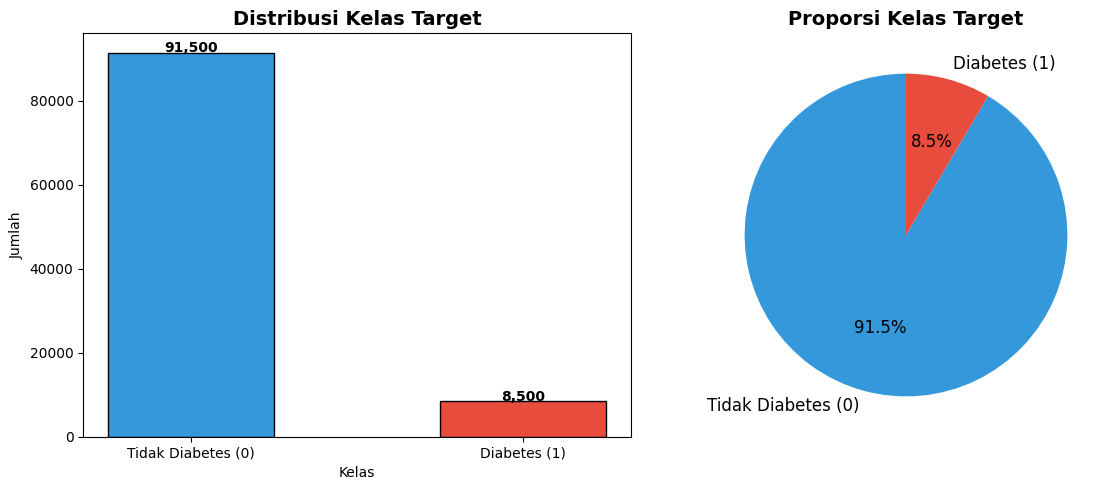

Distribusi Target:
diabetes
0    91500
1     8500
Name: count, dtype: int64

Rasio imbalance: 10.8:1


In [7]:
# ============================================================
# 4.3 DISTRIBUSI TARGET VARIABLE (diabetes)
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Countplot
target_counts = df['diabetes'].value_counts()
labels = ['Tidak Diabetes (0)', 'Diabetes (1)']
colors = ['#3498db', '#e74c3c']

axes[0].bar(labels, target_counts.values, color=colors, edgecolor='black', width=0.5)
axes[0].set_title('Distribusi Kelas Target', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Kelas')
axes[0].set_ylabel('Jumlah')
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 100, f'{v:,}', ha='center', fontweight='bold')

# Pie chart
axes[1].pie(target_counts.values, labels=labels, colors=colors,
            autopct='%1.1f%%', startangle=90, textprops={'fontsize': 12})
axes[1].set_title('Proporsi Kelas Target', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print('Distribusi Target:')
print(target_counts)
print(f'\nRasio imbalance: {target_counts[0]/target_counts[1]:.1f}:1')

## 4.4 Distribusi Fitur Numerik

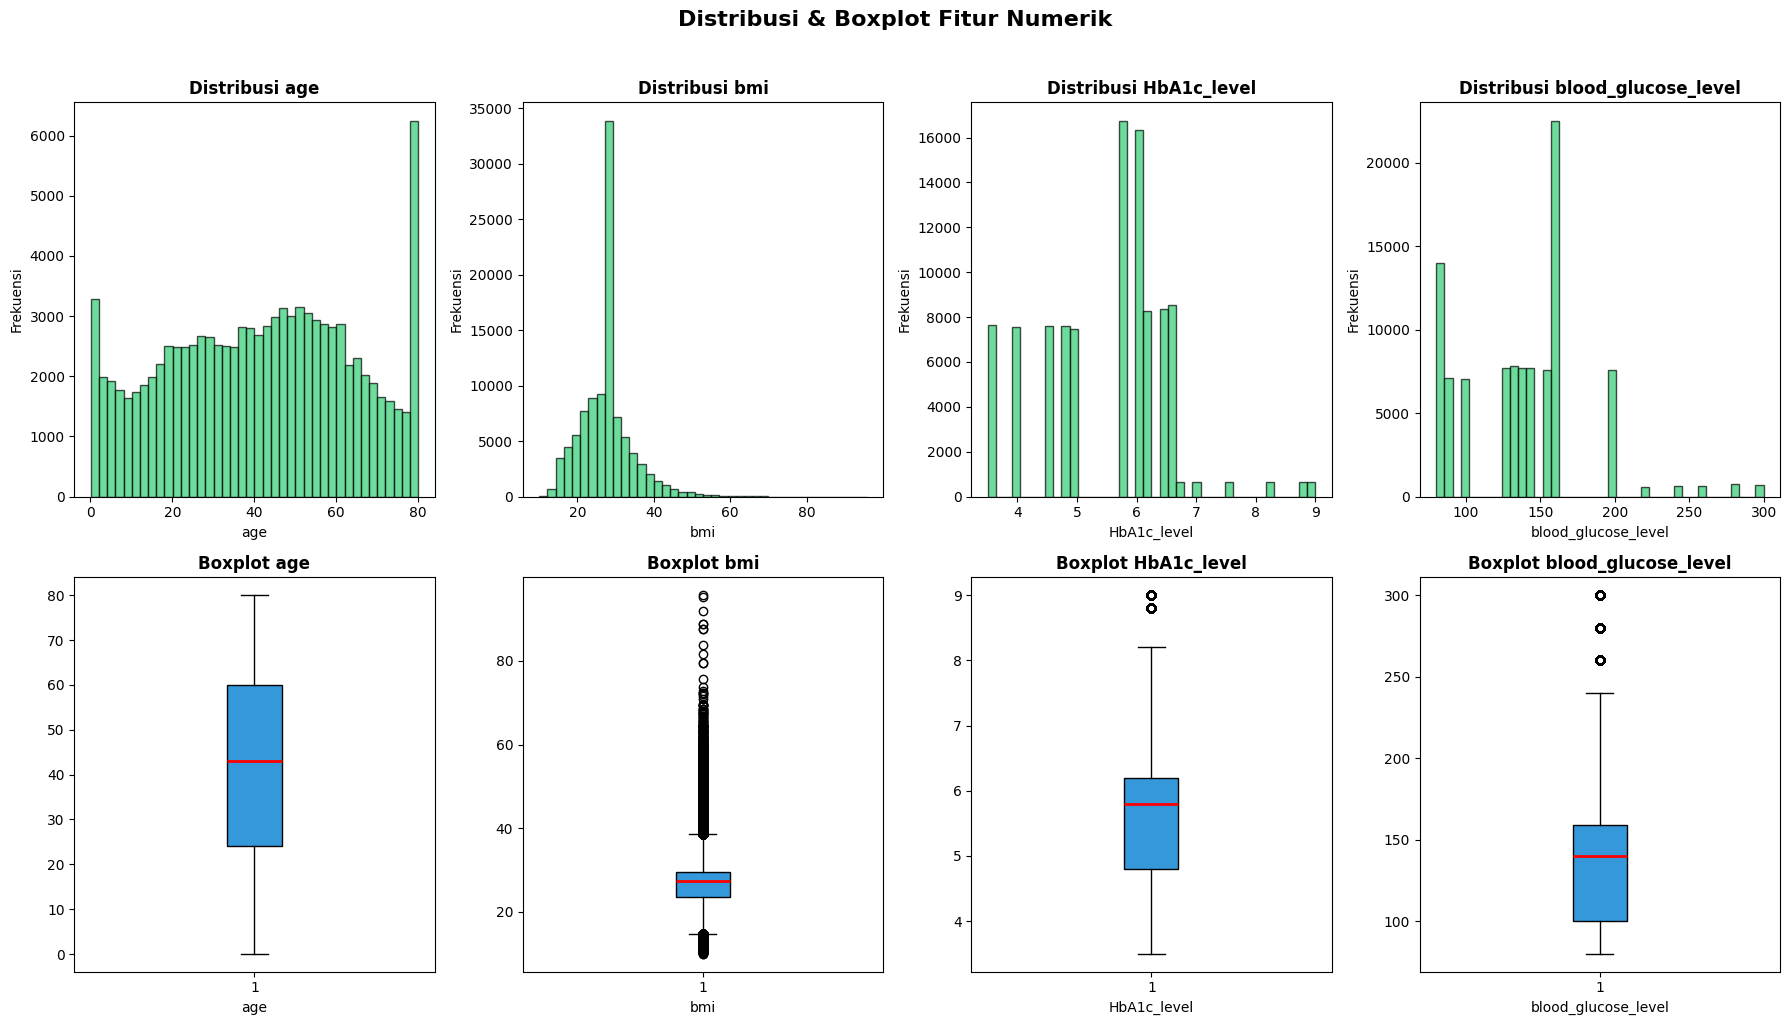

Statistik Fitur Numerik:


,age,bmi,HbA1c_level,blood_glucose_level
count,100000.00,100000.00,100000.00,100000.00
mean,41.89,27.32,5.53,138.06
std,22.52,6.64,1.07,40.71
min,0.08,10.01,3.50,80.00
25%,24.00,23.63,4.80,100.00
50%,43.00,27.32,5.80,140.00
75%,60.00,29.58,6.20,159.00
max,80.00,95.69,9.00,300.00


In [8]:
# ============================================================
# 4.4 DISTRIBUSI FITUR NUMERIK
# ============================================================

numerical_cols = ['age', 'bmi', 'HbA1c_level', 'blood_glucose_level']

fig, axes = plt.subplots(2, 4, figsize=(18, 10))

for i, col in enumerate(numerical_cols):
    # Histogram
    axes[0, i].hist(df[col], bins=40, color='#2ecc71', edgecolor='black', alpha=0.7)
    axes[0, i].set_title(f'Distribusi {col}', fontweight='bold')
    axes[0, i].set_xlabel(col)
    axes[0, i].set_ylabel('Frekuensi')

    # Boxplot
    axes[1, i].boxplot(df[col], patch_artist=True,
                       boxprops=dict(facecolor='#3498db', color='black'),
                       medianprops=dict(color='red', linewidth=2))
    axes[1, i].set_title(f'Boxplot {col}', fontweight='bold')
    axes[1, i].set_xlabel(col)

plt.suptitle('Distribusi & Boxplot Fitur Numerik', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('Statistik Fitur Numerik:')
df[numerical_cols].describe()

## 4.5 Distribusi Fitur Kategorikal

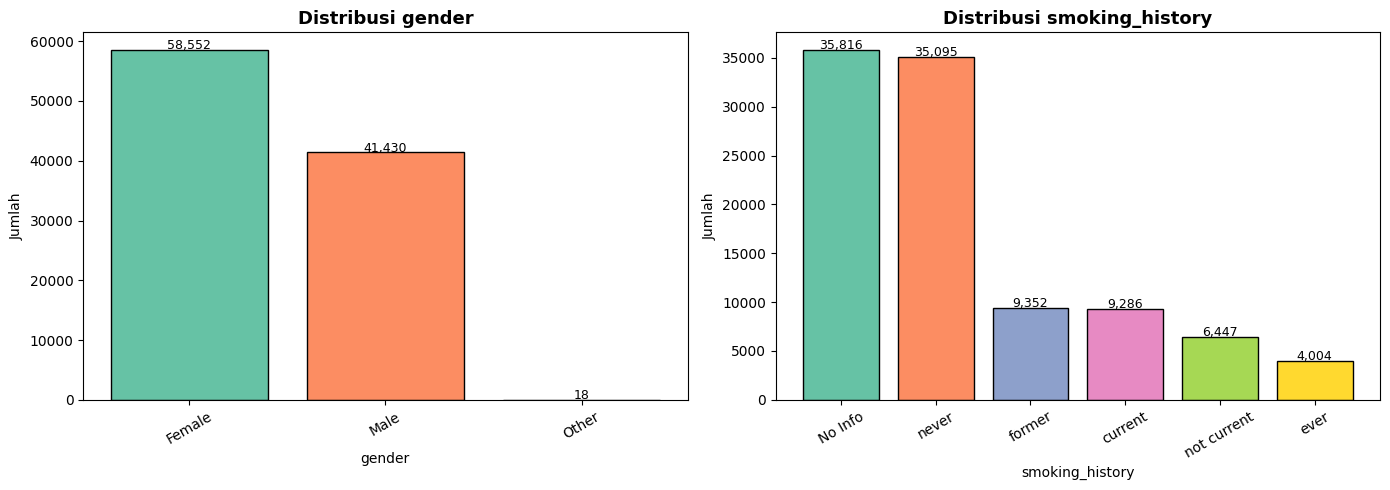

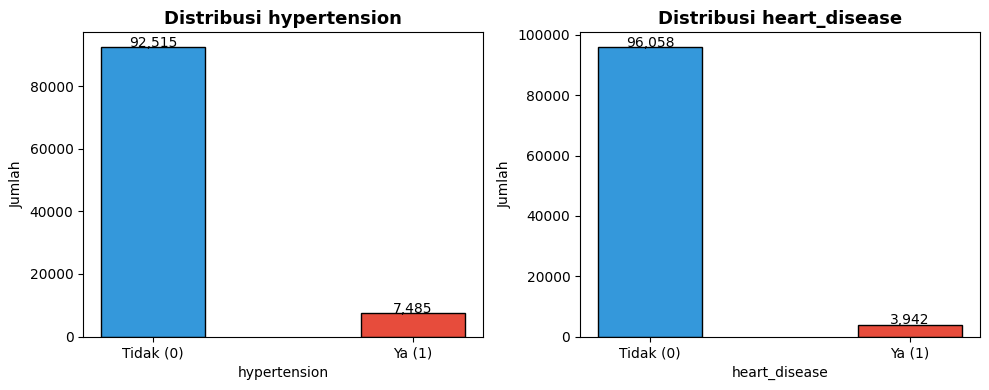

In [9]:
# ============================================================
# 4.5 DISTRIBUSI FITUR KATEGORIKAL
# ============================================================

categorical_cols = ['gender', 'smoking_history']
binary_cols = ['hypertension', 'heart_disease']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, col in enumerate(categorical_cols):
    counts = df[col].value_counts()
    axes[i].bar(counts.index, counts.values,
                color=sns.color_palette('Set2', len(counts)),
                edgecolor='black')
    axes[i].set_title(f'Distribusi {col}', fontweight='bold', fontsize=13)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Jumlah')
    axes[i].tick_params(axis='x', rotation=30)
    for j, v in enumerate(counts.values):
        axes[i].text(j, v + 100, f'{v:,}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

# Fitur biner
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for i, col in enumerate(binary_cols):
    counts = df[col].value_counts()
    axes[i].bar(['Tidak (0)', 'Ya (1)'], counts.values,
                color=['#3498db', '#e74c3c'], edgecolor='black', width=0.4)
    axes[i].set_title(f'Distribusi {col}', fontweight='bold', fontsize=13)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Jumlah')
    for j, v in enumerate(counts.values):
        axes[i].text(j, v + 100, f'{v:,}', ha='center')

plt.tight_layout()
plt.show()

## 4.6 Analisis Hubungan Fitur dengan Target

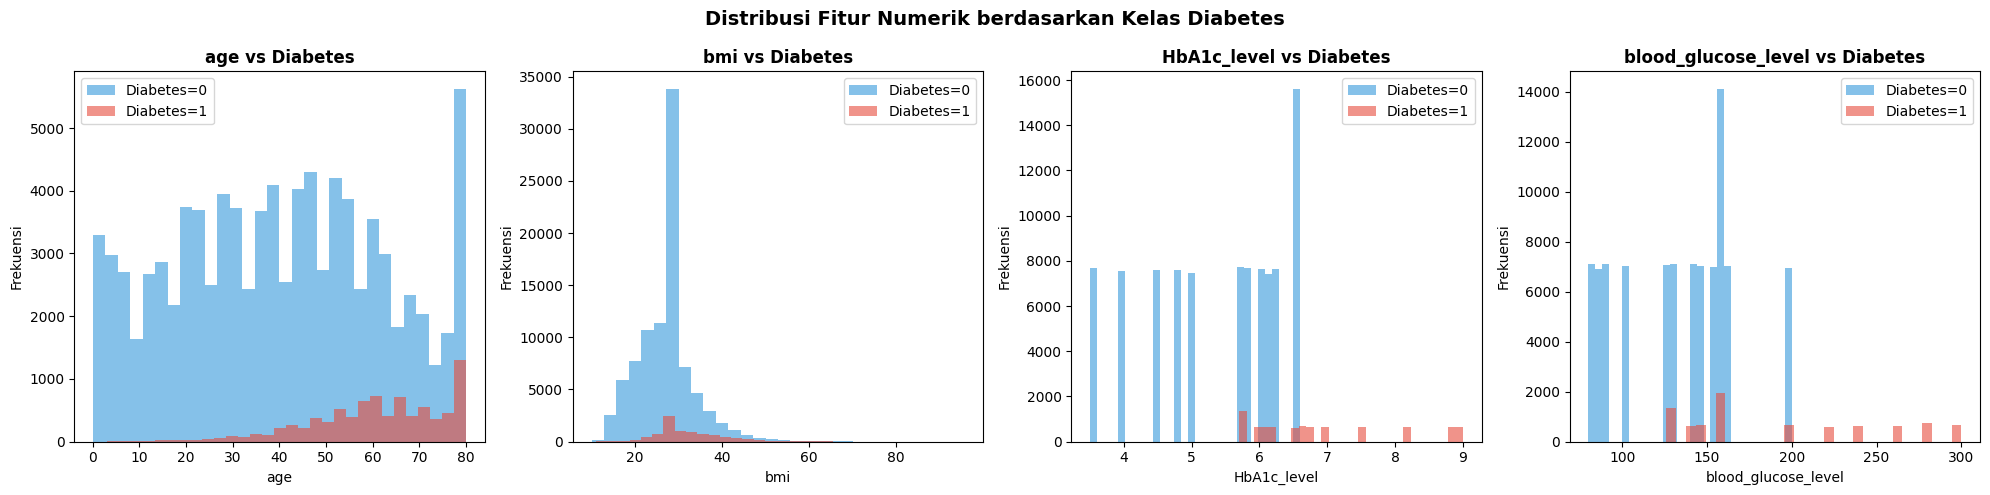

In [10]:
# ============================================================
# 4.6 HUBUNGAN FITUR NUMERIK DENGAN TARGET
# ============================================================

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for i, col in enumerate(numerical_cols):
    for label, color in zip([0, 1], ['#3498db', '#e74c3c']):
        subset = df[df['diabetes'] == label][col]
        axes[i].hist(subset, bins=30, alpha=0.6, color=color,
                     label=f'Diabetes={label}', edgecolor='none')
    axes[i].set_title(f'{col} vs Diabetes', fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frekuensi')
    axes[i].legend()

plt.suptitle('Distribusi Fitur Numerik berdasarkan Kelas Diabetes',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 4.7 Correlation Heatmap

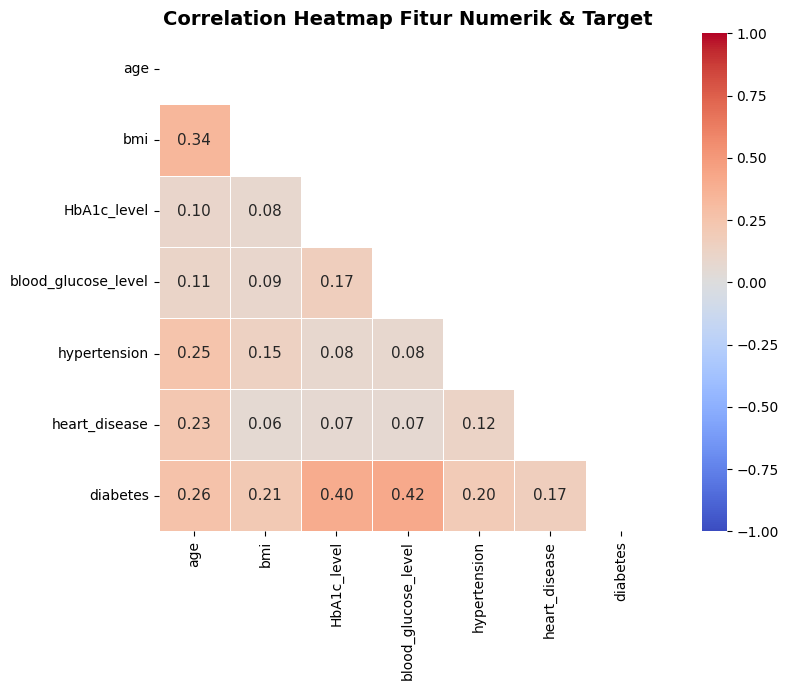

Korelasi terhadap Target (diabetes):
diabetes              1.00
blood_glucose_level   0.42
HbA1c_level           0.40
age                   0.26
bmi                   0.21
hypertension          0.20
heart_disease         0.17
Name: diabetes, dtype: float64


In [11]:
# ============================================================
# 4.7 CORRELATION HEATMAP
# ============================================================

numerical_df = df[numerical_cols + binary_cols + ['diabetes']]

corr_matrix = numerical_df.corr()

plt.figure(figsize=(10, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, center=0, square=True,
            linewidths=0.5, mask=mask,
            annot_kws={'size': 11})
plt.title('Correlation Heatmap Fitur Numerik & Target', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('Korelasi terhadap Target (diabetes):')
print(corr_matrix['diabetes'].sort_values(ascending=False))

## 4.8 Ringkasan Hasil EDA

In [12]:
# ============================================================
# 4.8 RINGKASAN HASIL EDA
# ============================================================

print('=' * 60)
print('RINGKASAN HASIL EDA')
print('=' * 60)
print(f'Total data       : {len(df):,} baris')
print(f'Jumlah fitur     : {df.shape[1] - 1} fitur + 1 target')
print(f'Missing values   : {df.isnull().sum().sum()} (tidak ada)')
print(f'Duplikat         : {df.duplicated().sum()}')
print()
print('Distribusi Target:')
print(f'  Tidak Diabetes : {(df["diabetes"]==0).sum():,} ({(df["diabetes"]==0).mean()*100:.1f}%)')
print(f'  Diabetes       : {(df["diabetes"]==1).sum():,} ({(df["diabetes"]==1).mean()*100:.1f}%)')
print()
print('Temuan Utama:')
print('  1. Dataset IMBALANCED - kelas 0 jauh lebih banyak dari kelas 1')
print('  2. blood_glucose_level & HbA1c_level korelasi tertinggi dengan target')
print('  3. Kolom smoking_history berisi nilai "No Info" yang perlu ditangani')
print('  4. Terdapat potensi outlier pada fitur bmi')
print('  5. Fitur gender & smoking_history perlu di-encode sebelum modeling')

RINGKASAN HASIL EDA
Total data       : 100,000 baris
Jumlah fitur     : 8 fitur + 1 target
Missing values   : 0 (tidak ada)
Duplikat         : 3854

Distribusi Target:
  Tidak Diabetes : 91,500 (91.5%)
  Diabetes       : 8,500 (8.5%)

Temuan Utama:
  1. Dataset IMBALANCED - kelas 0 jauh lebih banyak dari kelas 1
  2. blood_glucose_level & HbA1c_level korelasi tertinggi dengan target
  3. Kolom smoking_history berisi nilai "No Info" yang perlu ditangani
  4. Terdapat potensi outlier pada fitur bmi
  5. Fitur gender & smoking_history perlu di-encode sebelum modeling


# **5. Data Preprocessing**

Berdasarkan hasil EDA, berikut tahapan preprocessing yang akan dilakukan:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

In [13]:
# Salin dataframe agar data asli tidak termodifikasi
df_clean = df.copy()

# Definisikan kolom numerik untuk digunakan di beberapa tahap
numerical_cols = ['age', 'bmi', 'HbA1c_level', 'blood_glucose_level']

print('Salinan dataset siap untuk dipreprocess.')
print(f'Shape: {df_clean.shape}')

Salinan dataset siap untuk dipreprocess.
Shape: (100000, 9)


## 5.1 Menghapus atau Menangani Data Kosong (Missing Values)

In [14]:
# ============================================================
# 5.1 MENANGANI MISSING VALUES
# ============================================================

print('Pemeriksaan Missing Values:')
print('=' * 45)
missing_count = df_clean.isnull().sum()
missing_pct   = (df_clean.isnull().sum() / len(df_clean)) * 100
missing_df    = pd.DataFrame({
    'Missing Count': missing_count,
    'Missing (%)' : missing_pct
})
print(missing_df)
print()
print(f'Total missing values: {df_clean.isnull().sum().sum()}')

# Dataset ini tidak memiliki missing value secara eksplisit (NaN),
# namun kolom smoking_history memiliki nilai 'No Info' yang
# secara semantik merupakan data tidak diketahui — kita tangani di sini.
print()
print('Nilai unik smoking_history (termasuk implisit missing):')
print(df_clean['smoking_history'].value_counts())
print()

# Ganti 'No Info' dengan modus dari nilai yang diketahui
# sebagai penanganan implicit missing value
modus_smoking = df_clean[df_clean['smoking_history'] != 'No Info']['smoking_history'].mode()[0]
count_no_info = (df_clean['smoking_history'] == 'No Info').sum()
df_clean['smoking_history'] = df_clean['smoking_history'].replace('No Info', modus_smoking)

print(f"'No Info' sebanyak {count_no_info:,} baris diganti dengan modus: '{modus_smoking}'")
print()
print('Nilai unik smoking_history setelah penanganan:')
print(df_clean['smoking_history'].value_counts())

Pemeriksaan Missing Values:
                     Missing Count  Missing (%)
gender                           0         0.00
age                              0         0.00
hypertension                     0         0.00
heart_disease                    0         0.00
smoking_history                  0         0.00
bmi                              0         0.00
HbA1c_level                      0         0.00
blood_glucose_level              0         0.00
diabetes                         0         0.00

Total missing values: 0

Nilai unik smoking_history (termasuk implisit missing):
smoking_history
No Info        35816
never          35095
former          9352
current         9286
not current     6447
ever            4004
Name: count, dtype: int64

'No Info' sebanyak 35,816 baris diganti dengan modus: 'never'

Nilai unik smoking_history setelah penanganan:
smoking_history
never          70911
former          9352
current         9286
not current     6447
ever            4004
Name: coun

## 5.2 Menghapus Data Duplikat

In [15]:
# ============================================================
# 5.2 MENGHAPUS DATA DUPLIKAT
# ============================================================

before = len(df_clean)
print(f'Jumlah baris duplikat   : {df_clean.duplicated().sum():,}')

df_clean = df_clean.drop_duplicates()
after = len(df_clean)

print(f'Jumlah data sebelum     : {before:,}')
print(f'Jumlah data sesudah     : {after:,}')
print(f'Baris yang dihapus      : {before - after:,}')
print()
df_clean.head()

Jumlah baris duplikat   : 5,833
Jumlah data sebelum     : 100,000
Jumlah data sesudah     : 94,167
Baris yang dihapus      : 5,833



,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.00,0,1,never,25.19,6.60,140,0
1,Female,54.00,0,0,never,27.32,6.60,80,0
2,Male,28.00,0,0,never,27.32,5.70,158,0
3,Female,36.00,0,0,current,23.45,5.00,155,0
4,Male,76.00,1,1,current,20.14,4.80,155,0


## 5.3 Normalisasi atau Standarisasi Fitur

In [16]:
# ============================================================
# 5.3 NORMALISASI / STANDARISASI FITUR NUMERIK
# ============================================================
# Kita menggunakan StandardScaler (z-score normalization):
#   z = (x - mean) / std
# Cocok digunakan karena distribusi fitur cenderung normal/kontinu.
# Normalisasi dilakukan SEBELUM outlier treatment agar scaler
# tidak terpengaruh nilai ekstrem yang belum ditangani.
# Catatan: pada pipeline produksi, scaler di-fit hanya di train set.

cols_to_scale = ['age', 'bmi', 'HbA1c_level', 'blood_glucose_level']

print('Statistik SEBELUM Standarisasi:')
print(df_clean[cols_to_scale].describe().loc[['mean', 'std', 'min', 'max']].round(3))
print()

scaler = StandardScaler()
df_clean[cols_to_scale] = scaler.fit_transform(df_clean[cols_to_scale])

print('Statistik SETELAH Standarisasi (StandardScaler):')
print(df_clean[cols_to_scale].describe().loc[['mean', 'std', 'min', 'max']].round(3))
print()
print('Keterangan: mean ≈ 0 dan std ≈ 1 menandakan standarisasi berhasil.')

Statistik SEBELUM Standarisasi:
       age   bmi  HbA1c_level  blood_glucose_level
mean 41.78 27.32         5.54               138.30
std  22.50  6.84         1.07                41.01
min   0.08 10.01         3.50                80.00
max  80.00 95.69         9.00               300.00

Statistik SETELAH Standarisasi (StandardScaler):
       age   bmi  HbA1c_level  blood_glucose_level
mean -0.00  0.00        -0.00                 0.00
std   1.00  1.00         1.00                 1.00
min  -1.85 -2.53        -1.89                -1.42
max   1.70 10.00         3.22                 3.94

Keterangan: mean ≈ 0 dan std ≈ 1 menandakan standarisasi berhasil.


## 5.4 Deteksi dan Penanganan Outlier

Deteksi Outlier pada Fitur Numerik (setelah standarisasi):
------------------------------------------------------------
age                       -> Outlier:     0 | Batas: [-3.190, 3.209]
bmi                       -> Outlier: 4,798 | Batas: [-2.063, 1.862]
HbA1c_level               -> Outlier: 1,309 | Batas: [-2.638, 2.573]
blood_glucose_level       -> Outlier: 2,029 | Batas: [-3.092, 2.663]


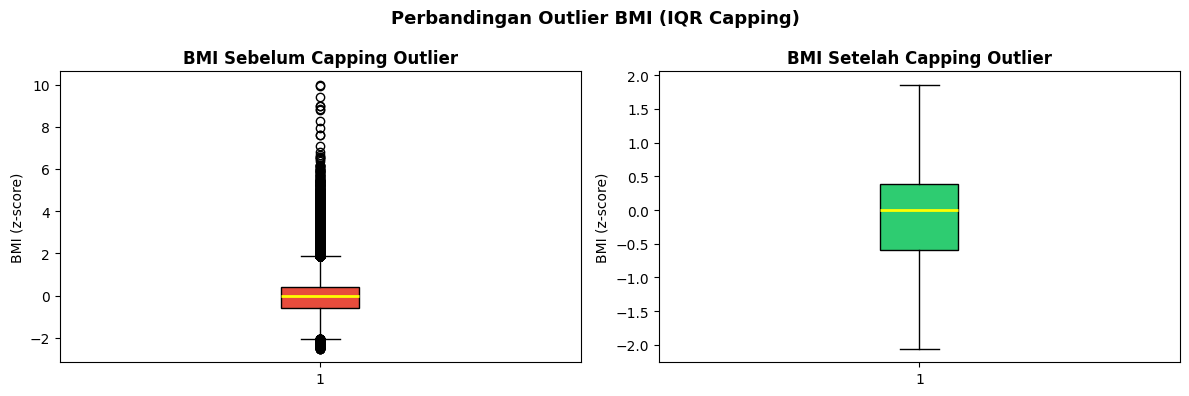


Capping outlier pada kolom "bmi" selesai.
Range bmi setelah capping: [-2.063, 1.862]


In [17]:
# ============================================================
# 5.4 DETEKSI DAN PENANGANAN OUTLIER (Metode IQR)
# ============================================================
# Setelah standarisasi, nilai ekstrem (outlier) terlihat lebih
# jelas karena sudah dalam skala yang sama (z-score).
# Kita deteksi menggunakan metode IQR dan tangani dengan capping.

def detect_outliers_iqr(df, column):
    Q1    = df[column].quantile(0.25)
    Q3    = df[column].quantile(0.75)
    IQR   = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((df[column] < lower) | (df[column] > upper)).sum()
    return lower, upper, n_out

def cap_outliers_iqr(df, column):
    Q1    = df[column].quantile(0.25)
    Q3    = df[column].quantile(0.75)
    IQR   = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df[column] = df[column].clip(lower=lower, upper=upper)
    return df

print('Deteksi Outlier pada Fitur Numerik (setelah standarisasi):')
print('-' * 60)
for col in cols_to_scale:
    lower, upper, n_out = detect_outliers_iqr(df_clean, col)
    print(f'{col:25s} -> Outlier: {n_out:5,} | Batas: [{lower:.3f}, {upper:.3f}]')

# Visualisasi boxplot sebelum & sesudah capping untuk kolom bmi
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].boxplot(df_clean['bmi'], patch_artist=True,
                boxprops=dict(facecolor='#e74c3c', color='black'),
                medianprops=dict(color='yellow', linewidth=2))
axes[0].set_title('BMI Sebelum Capping Outlier', fontweight='bold')
axes[0].set_ylabel('BMI (z-score)')

# Terapkan capping pada kolom bmi (outlier paling signifikan)
df_clean = cap_outliers_iqr(df_clean.copy(), 'bmi')

axes[1].boxplot(df_clean['bmi'], patch_artist=True,
                boxprops=dict(facecolor='#2ecc71', color='black'),
                medianprops=dict(color='yellow', linewidth=2))
axes[1].set_title('BMI Setelah Capping Outlier', fontweight='bold')
axes[1].set_ylabel('BMI (z-score)')

plt.suptitle('Perbandingan Outlier BMI (IQR Capping)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print()
print('Capping outlier pada kolom "bmi" selesai.')
print(f'Range bmi setelah capping: [{df_clean["bmi"].min():.3f}, {df_clean["bmi"].max():.3f}]')

## 5.5 Encoding Data Kategorikal

In [18]:
# ============================================================
# 5.5 ENCODING DATA KATEGORIKAL
# ============================================================
# Fitur kategorikal: 'gender' dan 'smoking_history'
# Metode: Label Encoding — digunakan karena jumlah kategori
# relatif kecil dan tidak memiliki hubungan ordinal yang kuat.

# --- Label Encoding: gender ---
le_gender = LabelEncoder()
df_clean['gender'] = le_gender.fit_transform(df_clean['gender'])
print('Mapping Encoding — gender:')
for i, cls in enumerate(le_gender.classes_):
    print(f'  {cls:10s} -> {i}')

print()

# --- Label Encoding: smoking_history ---
le_smoking = LabelEncoder()
df_clean['smoking_history'] = le_smoking.fit_transform(df_clean['smoking_history'])
print('Mapping Encoding — smoking_history:')
for i, cls in enumerate(le_smoking.classes_):
    print(f'  {cls:15s} -> {i}')

print()
print('Tipe data setelah encoding:')
print(df_clean[['gender', 'smoking_history']].dtypes)
print()
print('Preview dataset setelah encoding:')
df_clean.head()

Mapping Encoding — gender:
  Female     -> 0
  Male       -> 1
  Other      -> 2

Mapping Encoding — smoking_history:
  current         -> 0
  ever            -> 1
  former          -> 2
  never           -> 3
  not current     -> 4

Tipe data setelah encoding:
gender             int64
smoking_history    int64
dtype: object

Preview dataset setelah encoding:


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,0,1.70,0,1,3,-0.31,0.99,0.04,0
1,0,0.54,0,0,3,-0.00,0.99,-1.42,0
2,1,-0.61,0,0,3,-0.00,0.15,0.48,0
3,0,-0.26,0,0,0,-0.57,-0.50,0.41,0
4,1,1.52,1,1,0,-1.05,-0.68,0.41,0


## 5.6 Binning (Pengelompokan Data)

Distribusi Kelompok Usia (age_group):
----------------------------------------
  0 (Muda           ):  18,786 (19.9%)
  1 (Dewasa Awal    ):  26,475 (28.1%)
  2 (Dewasa Akhir   ):  31,558 (33.5%)
  3 (Lansia         ):  17,348 (18.4%)

Distribusi Kelompok BMI (bmi_group):
----------------------------------------
  0 (Kurus       ):  13,495 (14.3%)
  1 (Normal      ):  46,914 (49.8%)
  2 (Overweight  ):  21,456 (22.8%)
  3 (Obesitas    ):  12,302 (13.1%)



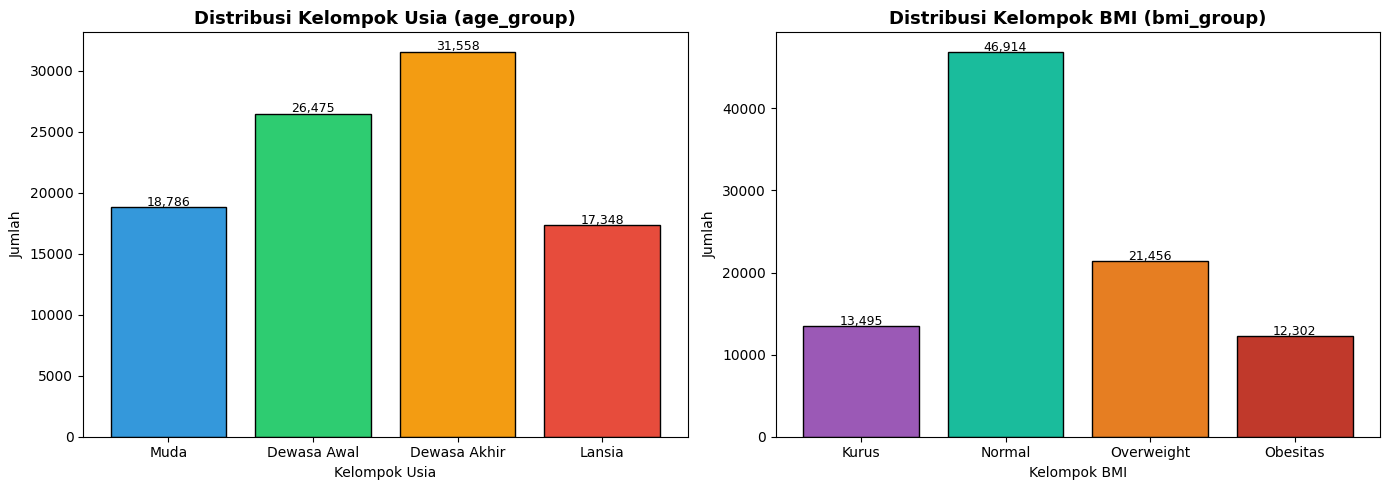

Kolom baru hasil binning: age_group, bmi_group
Preview dataset akhir:


,age,age_group,bmi,bmi_group,diabetes
0,1.70,3,-0.31,1,0
1,0.54,2,-0.00,1,0
2,-0.61,1,-0.00,1,0
3,-0.26,1,-0.57,1,0
4,1.52,3,-1.05,0,0
5,-0.97,1,-0.00,1,0
6,0.10,2,-1.17,0,1
7,1.65,3,-0.51,1,0
8,0.01,2,0.92,2,0
9,-0.43,1,-0.00,1,0


In [19]:
# ============================================================
# 5.6 BINNING (PENGELOMPOKAN DATA)
# ============================================================
# Binning dilakukan pada kolom 'age' (sebelum standarisasi
# nilai aslinya sudah tersimpan di df_age_raw untuk referensi).
# Karena 'age' sudah distandarisasi, kita lakukan binning
# berdasarkan nilai z-score-nya menjadi 4 kelompok usia.
#
# Binning berguna untuk:
#   - Menangkap pola non-linear pada fitur kontinu
#   - Mengurangi pengaruh noise pada rentang nilai tertentu
#   - Interpretasi model yang lebih mudah

# --- Binning usia berdasarkan z-score ---
age_bins   = [-float('inf'), -1.0, 0.0, 1.0, float('inf')]
age_labels = [0, 1, 2, 3]   # 0=Muda, 1=Dewasa Awal, 2=Dewasa Akhir, 3=Lansia

df_clean['age_group'] = pd.cut(
    df_clean['age'],
    bins=age_bins,
    labels=age_labels
).astype(int)

label_map = {0: 'Muda', 1: 'Dewasa Awal', 2: 'Dewasa Akhir', 3: 'Lansia'}
print('Distribusi Kelompok Usia (age_group):')
print('-' * 40)
for k, v in label_map.items():
    count = (df_clean['age_group'] == k).sum()
    pct   = count / len(df_clean) * 100
    print(f'  {k} ({v:15s}): {count:7,} ({pct:.1f}%)')

print()

# --- Binning BMI berdasarkan z-score ---
bmi_bins   = [-float('inf'), -1.0, 0.0, 1.0, float('inf')]
bmi_labels = [0, 1, 2, 3]   # 0=Kurus, 1=Normal, 2=Overweight, 3=Obesitas

df_clean['bmi_group'] = pd.cut(
    df_clean['bmi'],
    bins=bmi_bins,
    labels=bmi_labels
).astype(int)

bmi_label_map = {0: 'Kurus', 1: 'Normal', 2: 'Overweight', 3: 'Obesitas'}
print('Distribusi Kelompok BMI (bmi_group):')
print('-' * 40)
for k, v in bmi_label_map.items():
    count = (df_clean['bmi_group'] == k).sum()
    pct   = count / len(df_clean) * 100
    print(f'  {k} ({v:12s}): {count:7,} ({pct:.1f}%)')

print()

# --- Visualisasi Distribusi Binning ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

age_counts = df_clean['age_group'].value_counts().sort_index()
axes[0].bar([label_map[i] for i in age_counts.index], age_counts.values,
            color=['#3498db', '#2ecc71', '#f39c12', '#e74c3c'], edgecolor='black')
axes[0].set_title('Distribusi Kelompok Usia (age_group)', fontweight='bold', fontsize=13)
axes[0].set_xlabel('Kelompok Usia')
axes[0].set_ylabel('Jumlah')
for i, v in enumerate(age_counts.values):
    axes[0].text(i, v + 100, f'{v:,}', ha='center', fontsize=9)

bmi_counts = df_clean['bmi_group'].value_counts().sort_index()
axes[1].bar([bmi_label_map[i] for i in bmi_counts.index], bmi_counts.values,
            color=['#9b59b6', '#1abc9c', '#e67e22', '#c0392b'], edgecolor='black')
axes[1].set_title('Distribusi Kelompok BMI (bmi_group)', fontweight='bold', fontsize=13)
axes[1].set_xlabel('Kelompok BMI')
axes[1].set_ylabel('Jumlah')
for i, v in enumerate(bmi_counts.values):
    axes[1].text(i, v + 100, f'{v:,}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

print('Kolom baru hasil binning: age_group, bmi_group')
print('Preview dataset akhir:')
df_clean[['age', 'age_group', 'bmi', 'bmi_group', 'diabetes']].head(10)

## 5.7 Split Data & Simpan Hasil Preprocessing

In [20]:
# ============================================================
# 5.7 SPLIT DATA TRAIN / TEST & SIMPAN HASIL
# ============================================================

X = df_clean.drop('diabetes', axis=1)
y = df_clean['diabetes']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print('Hasil Split Data:')
print(f'  Total data   : {len(X):,}')
print(f'  Train set    : {len(X_train):,} ({len(X_train)/len(X)*100:.0f}%)')
print(f'  Test set     : {len(X_test):,} ({len(X_test)/len(X)*100:.0f}%)')
print()
print('Proporsi kelas Train set:')
print(y_train.value_counts(normalize=True).round(3))
print()
print('Proporsi kelas Test set:')
print(y_test.value_counts(normalize=True).round(3))

# Simpan ke CSV
import os
os.makedirs('diabetes_preprocessing', exist_ok=True)

df_train_out = X_train.copy()
df_train_out['diabetes'] = y_train.values

df_test_out = X_test.copy()
df_test_out['diabetes'] = y_test.values

df_train_out.to_csv('diabetes_preprocessing/diabetes_train_preprocessed.csv', index=False)
df_test_out.to_csv('diabetes_preprocessing/diabetes_test_preprocessed.csv', index=False)

print()
print('Dataset berhasil disimpan:')
print('  -> diabetes_preprocessing/diabetes_train_preprocessed.csv')
print('  -> diabetes_preprocessing/diabetes_test_preprocessed.csv')
print()
print('Preview data train hasil preprocessing:')
df_train_out.head()

Hasil Split Data:
  Total data   : 94,167
  Train set    : 75,333 (80%)
  Test set     : 18,834 (20%)

Proporsi kelas Train set:
diabetes
0   0.91
1   0.09
Name: proportion, dtype: float64

Proporsi kelas Test set:
diabetes
0   0.91
1   0.09
Name: proportion, dtype: float64

Dataset berhasil disimpan:
  -> diabetes_preprocessing/diabetes_train_preprocessed.csv
  -> diabetes_preprocessing/diabetes_test_preprocessed.csv

Preview data train hasil preprocessing:


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,age_group,bmi_group,diabetes
9265,0,0.14,0,0,2,-0.38,0.62,-0.93,2,1,0
58296,1,-0.08,0,0,4,-0.33,0.25,0.04,1,1,0
65884,0,1.48,0,0,4,-0.00,-1.43,0.48,3,1,0
26268,0,1.25,0,0,3,1.86,1.18,-0.20,3,3,1
77598,1,0.77,0,0,2,0.45,-0.68,0.48,2,2,0


## 5.8 Ringkasan Tahapan Preprocessing

In [21]:
# ============================================================
# 5.8 RINGKASAN PREPROCESSING
# ============================================================

print('=' * 62)
print('      RINGKASAN TAHAPAN DATA PREPROCESSING')
print('=' * 62)

print('1. Menghapus/Menangani Missing Values')
print(f'   Tidak ada NaN eksplisit.')
print(f"   'No Info' pada smoking_history ({count_no_info:,} baris) diganti modus: '{modus_smoking}'")
print()

print('2. Menghapus Data Duplikat')
print(f'   Sebelum : {before:,} baris')
print(f'   Sesudah : {after:,} baris  (dihapus: {before-after:,})')
print()

print('3. Normalisasi / Standarisasi Fitur')
print('   Metode  : StandardScaler (z-score)')
print(f'   Kolom   : {cols_to_scale}')
print()

print('4. Deteksi dan Penanganan Outlier')
print('   Metode  : IQR Capping')
print('   Kolom   : bmi')
print()

print('5. Encoding Data Kategorikal')
print('   Metode  : Label Encoding')
print('   Kolom   : gender, smoking_history')
print()

print('6. Binning (Pengelompokan Data)')
print('   age  -> age_group  (0: Muda | 1: Dewasa Awal | 2: Dewasa Akhir | 3: Lansia)')
print('   bmi  -> bmi_group  (0: Kurus | 1: Normal | 2: Overweight | 3: Obesitas)')
print()

print('Split Data')
print(f'   Train : {len(X_train):,} baris | Test: {len(X_test):,} baris | Rasio: 80:20')
print()
print('Data siap untuk proses pelatihan model!')
print('=' * 62)

      RINGKASAN TAHAPAN DATA PREPROCESSING
1. Menghapus/Menangani Missing Values
   Tidak ada NaN eksplisit.
   'No Info' pada smoking_history (35,816 baris) diganti modus: 'never'

2. Menghapus Data Duplikat
   Sebelum : 100,000 baris
   Sesudah : 94,167 baris  (dihapus: 5,833)

3. Normalisasi / Standarisasi Fitur
   Metode  : StandardScaler (z-score)
   Kolom   : ['age', 'bmi', 'HbA1c_level', 'blood_glucose_level']

4. Deteksi dan Penanganan Outlier
   Metode  : IQR Capping
   Kolom   : bmi

5. Encoding Data Kategorikal
   Metode  : Label Encoding
   Kolom   : gender, smoking_history

6. Binning (Pengelompokan Data)
   age  -> age_group  (0: Muda | 1: Dewasa Awal | 2: Dewasa Akhir | 3: Lansia)
   bmi  -> bmi_group  (0: Kurus | 1: Normal | 2: Overweight | 3: Obesitas)

Split Data
   Train : 75,333 baris | Test: 18,834 baris | Rasio: 80:20

Data siap untuk proses pelatihan model!
